# Lab: The Indefinite Integral and the Mass of the Earth

Math 140H, Honors Calculus I

So far we have mostly treated an integral as a single number. In this lab the object of interest is the **indefinite integral**

$$\Phi(x) = \int_\alpha^x f(u)\,du,$$

the integral viewed as a function of its upper limit. Our $f$ comes from real geophysical data: the density of the Earth as a function of distance from its center. The indefinite integral

$$M(x) = \int_0^x 4\pi u^2 \rho(u)\,du$$

is then the mass of the Earth lying within distance $x$ of the center. 

- Recall: **$4\pi u^2$ is the surface of a sphere of radius $u$**. How does this help explain the integrand $4\pi u^2 \rho(u)$ above?

We will build $M$ from Riemann sums, check it against Earth's known mass, see that it is continuous even though $\rho$ is not, and then use it to answer questions that need the whole function, not just one value of it.

- Cells marked **PREDICT** ask you to write down a guess before running the next code cell. Do not skip them: the point is to find out whether your intuition about $M$ is right.

The data come from the Preliminary Reference Earth Model (PREM) of Dziewonski and Anderson (1981), the standard one-dimensional model of Earth's interior used in seismology. It was built by fitting seismic travel times, Earth's free oscillations, its total mass, and its moment of inertia.

In [1]:
#
# RUN THIS FIRST
# Imports basic python libraries and defines constants
#

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (7, 4.5)
plt.rcParams['axes.grid'] = True
rng = np.random.default_rng(140)

a = 6371.0e3          # Earth's radius in meters
G = 6.6743e-11        # gravitational constant, m^3 kg^-1 s^-2
M_known = 5.9722e24   # Earth's mass in kg, measured independently from satellite orbits

## Part 1: The density function

PREM splits the Earth into spherical layers. Inside each layer the density is a polynomial (of degree at most 3) in the normalized radius $x = r/a$, where $a = 6371$ km is Earth's radius. The table below lists each layer's inner and outer radius in km and the polynomial coefficients $c_0, c_1, c_2, c_3$, so that

$$\rho = c_0 + c_1 x + c_2 x^2 + c_3 x^3 \quad \text{grams per cubic centimeter}.$$

(Several thin seismic layers in the lower mantle and upper mantle share a density polynomial, so they are merged here.)

**PREDICT** (on paper, before running anything):
- Sketch what you think the density looks like from the center ($r = 0$) out to the surface ($r = a$). Surface rocks have density around 2.7 g/cm³, and water is 1.
- Do you expect the density to be a continuous function of $r$?

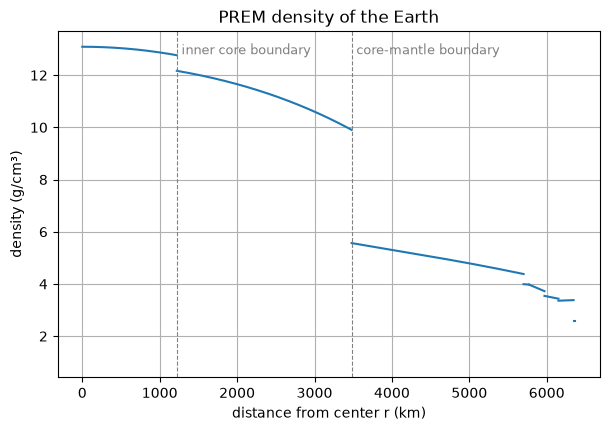

In [2]:
# PREM density: (inner radius km, outer radius km, name, [c0, c1, c2, c3]) with x = r / a
PREM_LAYERS = [
    (   0.0, 1221.5, 'inner core',        [13.0885,  0.0,    -8.8381,  0.0   ]),
    (1221.5, 3480.0, 'outer core',        [12.5815, -1.2638, -3.6426, -5.5281]),
    (3480.0, 5701.0, 'lower mantle',      [ 7.9565, -6.4761,  5.5283, -3.0807]),
    (5701.0, 5771.0, 'transition zone 1', [ 5.3197, -1.4836,  0.0,     0.0   ]),
    (5771.0, 5971.0, 'transition zone 2', [11.2494, -8.0298,  0.0,     0.0   ]),
    (5971.0, 6151.0, 'transition zone 3', [ 7.1089, -3.8045,  0.0,     0.0   ]),
    (6151.0, 6346.6, 'upper mantle',      [ 2.6910,  0.6924,  0.0,     0.0   ]),
    (6346.6, 6356.0, 'lower crust',       [ 2.900,   0.0,     0.0,     0.0   ]),
    (6356.0, 6368.0, 'upper crust',       [ 2.600,   0.0,     0.0,     0.0   ]),
    (6368.0, 6371.0, 'ocean',             [ 1.020,   0.0,     0.0,     0.0   ]),
]
BOUNDARIES = np.array([L[1] for L in PREM_LAYERS]) * 1e3   # outer radii in meters
R_ICB = 1221.5e3   # inner core boundary
R_CMB = 3480.0e3   # core-mantle boundary

def rho(r):
    # PREM density at radius r (meters), in kg/m^3. Works on numbers or numpy arrays.
    r = np.asarray(r, dtype=float)
    idx = np.searchsorted(BOUNDARIES, r, side='right')
    idx = np.clip(idx, 0, len(PREM_LAYERS) - 1)
    coeffs = np.array([L[3] for L in PREM_LAYERS])[idx]      # shape (..., 4)
    x = r / a
    powers = np.stack([np.ones_like(x), x, x**2, x**3], axis=-1)
    return 1000.0 * np.sum(coeffs * powers, axis=-1)         # g/cm^3 -> kg/m^3

def plot_rho(**kwargs):
    # plot rho layer by layer so the jumps are not drawn as vertical line segments
    for k, (r0, r1, name, c) in enumerate(PREM_LAYERS):
        rr = np.linspace(r0 * 1e3, r1 * 1e3 - 1e-6, 400)
        plt.plot(rr / 1e3, rho(rr) / 1000, color='C0', **(kwargs if k == 0 else {}))

plot_rho()
for rb, label in [(R_ICB, 'inner core boundary'), (R_CMB, 'core-mantle boundary')]:
    plt.axvline(rb / 1e3, color='gray', linestyle='--', linewidth=0.8)
    plt.text(rb / 1e3 + 60, 12.8, label, fontsize=9, color='gray')
plt.xlabel('distance from center r (km)')
plt.ylabel('density (g/cm³)')
plt.title('PREM density of the Earth')
plt.show()

**VERIFY: Compare the plot with your sketch.**

- Where does the density jump? The two big jumps are where the solid inner core meets the liquid outer core, and where the iron core meets the rocky mantle.
- $\rho$ is not continuous, but it is still integrable: it is continuous on each of finitely many closed pieces, and our integral handles finitely many jumps without trouble (the jumps contribute nothing to the area in the limit).
- Explain in one sentence why a single jump cannot affect the limit of the Riemann sums.

## Part 2: The mass of the Earth from Riemann sums

Cut the Earth into $n$ thin concentric shells of thickness $\Delta u = a/n$. The shell between radius $u_{i-1}$ and $u_i$ has volume close to $4\pi u_i^2\,\Delta u$ (surface area times thickness), and its density is close to $\rho(u_i)$. So the mass is close to

$$\sum_{i=1}^n 4\pi u_i^2 \rho(u_i)\,\Delta u,$$

which is a Riemann sum for

$$M_{\text{total}} = \int_0^a 4\pi u^2 \rho(u)\,du.$$

**PREDICT:** 

The Earth's mass is known independently, from the orbits of the Moon and satellites, to be about $5.972 \times 10^{24}$ kg. PREM was fitted to match it. How many shells do you think we need before our Riemann sum agrees with this to 3 significant figures? 10? 100? 10,000?

In [3]:
def shell_integrand(u):
    return 4 * np.pi * u**2 * rho(u)

def riemann_mass(n, rule='right'):
    du = a / n
    i = np.arange(1, n + 1)
    if rule == 'left':
        u = (i - 1) * du
    elif rule == 'right':
        u = i * du
    else:                      # midpoint
        u = (i - 0.5) * du
    return np.sum(shell_integrand(u)) * du

print(f'{"n":>9}  {"left sum":>12}  {"right sum":>12}  {"midpoint":>12}   rel. error (midpoint)')
for n in [10, 100, 1000, 10_000, 100_000, 1_000_000]:
    L, R, Mid = (riemann_mass(n, rule) for rule in ['left', 'right', 'mid'])
    print(f'{n:>9}  {L:12.5e}  {R:12.5e}  {Mid:12.5e}   {abs(Mid - M_known) / M_known:.2e}')

        n      left sum     right sum      midpoint   rel. error (midpoint)
       10   5.43603e+24   5.76749e+24   5.76895e+24   3.40e-02
      100   5.92308e+24   5.95623e+24   5.99710e+24   4.17e-03
     1000   5.97270e+24   5.97601e+24   5.97469e+24   4.17e-04
    10000   5.97323e+24   5.97356e+24   5.97289e+24   1.15e-04
   100000   5.97314e+24   5.97318e+24   5.97321e+24   1.70e-04
  1000000   5.97318e+24   5.97318e+24   5.97318e+24   1.64e-04


**NOTE:**

- The relative error of the midpoint sums levels off around $1.6\times10^{-4}$. That is not a flaw in the Riemann sums: they converge to the mass of the PREM model, which differs from the modern measured value in the fourth significant figure. 

## Part 3: The indefinite integral M(x)

Now let the upper limit vary:

$$M(x) = \int_0^x 4\pi u^2 \rho(u)\,du = \text{mass of Earth within distance } x \text{ of the center}.$$

**PREDICT:**
- $\rho$ jumps at the inner core boundary and at the core-mantle boundary. Will the graph of $M$ jump there too? Will it have visible corners?
- What fraction of Earth's mass do you think lies inside the core ($r < 3480$ km)? The core makes up only $(3480/6371)^3 \approx 16\%$ of Earth's volume.

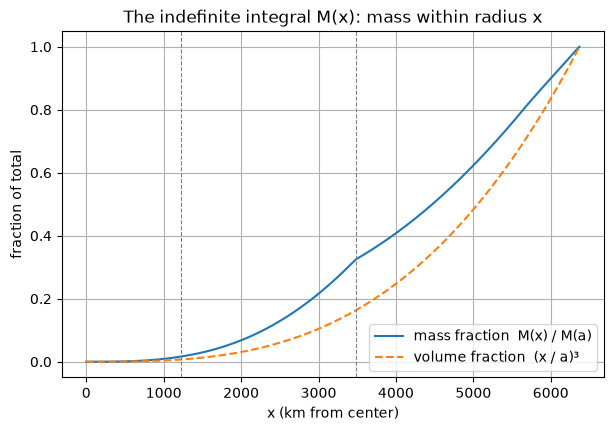

Core: 16.3% of the volume, 32.5% of the mass


In [4]:
n = 100_000
du = a / n
u_grid = (np.arange(1, n + 1) - 0.5) * du                 # midpoints
M_cum = np.concatenate([[0.0], np.cumsum(shell_integrand(u_grid)) * du])
x_grid = np.linspace(0, a, n + 1)                         # M_cum[k] approximates M(x_grid[k])
M_total = M_cum[-1]

plt.plot(x_grid / 1e3, M_cum / M_total, label='mass fraction  M(x) / M(a)')
plt.plot(x_grid / 1e3, (x_grid / a)**3, '--', label='volume fraction  (x / a)³')
for rb in [R_ICB, R_CMB]:
    plt.axvline(rb / 1e3, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel('x (km from center)')
plt.ylabel('fraction of total')
plt.title('The indefinite integral M(x): mass within radius x')
plt.legend()
plt.show()

M_core = np.interp(R_CMB, x_grid, M_cum)
print(f'Core: {100 * (R_CMB / a)**3:.1f}% of the volume, {100 * M_core / M_total:.1f}% of the mass')

**OBSERVE:**

- $M$ is continuous even though $\rho$ is not. The continuity of $M$ is due to a a quantitative bound. If $K$ is the largest value of $4\pi u^2 \rho(u)$ on $[0, a]$, then for any $x, y$,
$$|M(y) - M(x)| = \left|\int_x^y 4\pi u^2\rho(u)\,du\right| \le K\,|y - x|.$$
So $M$ is Lipschitz continuous. The next cell computes $K$ and tests the bound on random pairs of points.

- At the jumps of $\rho$, the graph of $M$ has a corner, a change in steepness, but no break.
- Why does the mass curve lie above the volume curve for every $x$ between 0 and $a$? What would the picture look like if the density were constant?



In [5]:
K = np.max(shell_integrand(np.linspace(0, a, 200_001)))
print(f'K = max of 4 pi u^2 rho(u) = {K:.3e} kg per meter of radius')

i, j = rng.integers(0, n + 1, size=(2, 10_000))
mask = i != j
ratios = np.abs(M_cum[i[mask]] - M_cum[j[mask]]) / np.abs(x_grid[i[mask]] - x_grid[j[mask]])
print(f'largest |M(y) - M(x)| / |y - x| over 10,000 random pairs: {ratios.max():.3e}')
print('bound holds:', ratios.max() <= K)

# where is the integrand largest?
u_fine = np.linspace(0, a, 200_001)
print(f'the integrand is largest at r = {u_fine[np.argmax(shell_integrand(u_fine))] / 1e3:.0f} km')

K = max of 4 pi u^2 rho(u) = 1.789e+18 kg per meter of radius
largest |M(y) - M(x)| / |y - x| over 10,000 random pairs: 1.781e+18
bound holds: True
the integrand is largest at r = 5701 km


**VERIFY:**

Where is the integrand $4\pi u^2\rho(u)$ largest, and why is that a sensible place? (Think about which shells are both dense and large.) That is where $M$ is steepest.

## Part 4: Exact values from the power rule

Because $\rho$ is a polynomial on each layer, so is $4\pi u^2\rho(u)$, and we can integrate it exactly using the rules for power functions:

$$\int_\alpha^\beta u^p\,du = \frac{\beta^{p+1} - \alpha^{p+1}}{p+1}.$$

Writing $u = a\,s$ (so $s$ is the normalized radius), the contribution of a layer from $s_0$ to $s_1$ with coefficients $c_0,\dots,c_3$ is

$$4\pi a^3 \sum_{k=0}^{3} c_k \,\frac{s_1^{k+3} - s_0^{k+3}}{k+3}.$$

By additivity, $M(x)$ is the sum of the contributions of all the layers below $x$, plus the partial contribution of the layer containing $x$.

In [6]:
def M_exact(x):
    # Exact PREM mass (kg) inside radius x (meters), from the power rule plus additivity
    s_x = x / a
    total = 0.0
    for r0, r1, name, c in PREM_LAYERS:
        s0, s1 = r0 * 1e3 / a, min(r1 * 1e3, x) / a
        if s1 <= s0:
            break
        for k, ck in enumerate(c):
            total += ck * (s1**(k + 3) - s0**(k + 3)) / (k + 3)
    return 4 * np.pi * a**3 * total * 1000.0    # g/cm^3 -> kg/m^3

for x_km in [1221.5, 3480.0, 5000.0, 6371.0]:
    exact = M_exact(x_km * 1e3)
    approx = np.interp(x_km * 1e3, x_grid, M_cum)
    print(f'x = {x_km:7.1f} km:  exact M = {exact:.6e} kg,  Riemann (n = {n:,}) = {approx:.6e} kg')

x =  1221.5 km:  exact M = 9.843333e+22 kg,  Riemann (n = 100,000) = 9.843333e+22 kg
x =  3480.0 km:  exact M = 1.939549e+24 kg,  Riemann (n = 100,000) = 1.939549e+24 kg
x =  5000.0 km:  exact M = 3.722904e+24 kg,  Riemann (n = 100,000) = 3.722925e+24 kg
x =  6371.0 km:  exact M = 5.973177e+24 kg,  Riemann (n = 100,000) = 5.973213e+24 kg


**VERIFY:**

The exact total mass should match the limit you saw the Riemann sums approaching in Part 2. How many digits do the Riemann sums with $n = 100{,}000$ get right?

## Part 5: Inverting M

Many natural questions ask for the $x$ at which $M$ takes a given value. For example: what radius contains exactly half of Earth's mass?

To answer we must solve $M(x) = \tfrac12 M(a)$. A solution exists by the intermediate value theorem, because $M$ is continuous with $M(0) = 0 < \tfrac12 M(a)$. It is unique because $M$ is strictly increasing: $\rho > 0$, so every shell adds positive mass. And we can locate it by bisection, which produces a sequence of nested intervals closing in on the answer.

**PREDICT:** 

Write down a guess for the radius containing half of Earth's mass, as a fraction of $a$. For comparison, the sphere containing half of Earth's *volume* has radius $a/\sqrt[3]{2} \approx 0.794\,a$. (This is the same number as the half-full mark on a conical cocktail glass. Why?)

In [7]:
def solve_increasing(F, target, lo, hi, tol=1.0):
    # Bisection for F(x) = target, F continuous and increasing on [lo, hi]. tol in meters.
    steps = 0
    while hi - lo > tol:
        mid = (lo + hi) / 2
        if F(mid) < target:
            lo = mid
        else:
            hi = mid
        steps += 1
    return (lo + hi) / 2, steps

M_a = M_exact(a)
x_half, steps = solve_increasing(M_exact, 0.5 * M_a, 0.0, a)
print(f'half of the mass lies within {x_half / 1e3:.1f} km of the center  ({x_half / a:.3f} a), found in {steps} bisection steps')
print(f'half of the volume lies within {a / 2**(1/3) / 1e3:.1f} km of the center  ({1 / 2**(1/3):.3f} a)')
print(f'depth of the half-mass sphere below the surface: {(a - x_half) / 1e3:.0f} km')

half of the mass lies within 4470.1 km of the center  (0.702 a), found in 23 bisection steps
half of the volume lies within 5056.7 km of the center  (0.794 a)
depth of the half-mass sphere below the surface: 1901 km


**VERIFY:** 

Is the half-mass radius in the core or the mantle? Explain why it must be smaller than the half-volume radius, using the fact that the mass curve in Part 3 lies above the volume curve.

**Try it yourself:** 
Using the cell below, find the radius containing **90% of Earth's mass**. How deep below the surface is it? What does that say about how much of Earth's mass is in the outer few hundred kilometers that we can study directly?

In [14]:
# EDIT HERE: choose a fraction of Earth's mass
fraction = 0.5   # EDIT this value to compute this for other fractions of Earth's mass

x_f, _ = solve_increasing(M_exact, fraction * M_a, 0.0, a)
print(f'{100 * fraction:.0f}% of the mass lies within {x_f / 1e3:.1f} km of the center, '
      f'i.e. deeper than {(a - x_f) / 1e3:.0f} km below the surface')

50% of the mass lies within 4470.1 km of the center, i.e. deeper than 1901 km below the surface


In [ ]:
x_vals = np.linspace(1e3, a, 2000)
rho_bar = np.array([M_exact(x) / (4 / 3 * np.pi * x**3) for x in x_vals])

plot_rho(label='density ρ(r)')
plt.plot(x_vals / 1e3, rho_bar / 1000, label='average density inside radius x')
plt.xlabel('r or x (km from center)')
plt.ylabel('g/cm³')
plt.legend()
plt.title('Density versus average density')
plt.show()

print(f'average density of the whole Earth: {rho_bar[-1] / 1000:.3f} g/cm³')

# For each x, is the average density attained by rho somewhere on [0, x]?
# rho is continuous on each layer, so on each layer it takes every value between its min and max there.
def attained(value, x):
    for r0, r1, name, c in PREM_LAYERS:
        lo, hi = r0 * 1e3, min(r1 * 1e3, x)
        if hi <= lo:
            break
        vals = rho(np.linspace(lo, hi - 1e-6, 400))
        if vals.min() <= value <= vals.max():
            return True
    return False

ok = np.array([attained(rb, x) for x, rb in zip(x_vals, rho_bar)])
# report the stretches of x where the average density is not attained
runs, start = [], None
for k, good in enumerate(ok):
    if not good and start is None:
        start = k
    if good and start is not None:
        runs.append((x_vals[start], x_vals[k - 1])); start = None
if start is not None:
    runs.append((x_vals[start], x_vals[-1]))
for lo, hi in runs:
    print(f'the average density is NOT attained by ρ on [0, x] for x from about {lo / 1e3:.0f} to {hi / 1e3:.0f} km')
if not runs:
    print('the average is attained for every x tested')

VERIFY and explain:
- For which $x$ does the mean value conclusion fail? Read off from the plot which ranges of density values the function $\rho$ *never* takes (look at the jumps at the inner core boundary and the core-mantle boundary), and check that $\bar\rho(x)$ passes through those ranges exactly for the values of $x$ printed above.
- Which hypothesis of the mean value theorem is violated, and where in the proof is it used? (The proof applies the intermediate value theorem to $\rho$.)
- For $x = a$ the conclusion does hold. Find a radius $\xi$ where $\rho(\xi)$ equals Earth's average density. Is it in the core or the mantle?